In [ ]:
# SLURM Failure Analysis
import glob
import re
from collections import defaultdict

def analyze_failures():
    """Quick analysis of SLURM failures"""
    slurm_files = glob.glob('./slurm-*.out')
    
    failed_jobs = []
    successful_jobs = []
    
    for filepath in slurm_files:
        try:
            with open(filepath, 'r') as f:
                content = f.read()
            
            job_id = filepath.replace('./slurm-', '').replace('.out', '')
            
            # Extract parameters
            device_match = re.search(r'device (\w+), lambda=([0-9\.e\-]+), supervised=(\w+)', content)
            params = {}
            if device_match:
                params = {
                    'lambda': float(device_match.group(2)),
                    'supervised': device_match.group(3) == 'True'
                }
            
            if 'Traceback' in content:
                if 'Cannot take a larger sample than population' in content:
                    failed_jobs.append({'job_id': job_id, 'error': 'SAMPLING_ERROR', 'params': params})
                else:
                    failed_jobs.append({'job_id': job_id, 'error': 'OTHER_ERROR', 'params': params})
            elif 'results_seed=' in content:
                successful_jobs.append({'job_id': job_id, 'params': params})
                
        except Exception as e:
            print(f"Error reading {filepath}: {e}")
    
    print(f"Total SLURM jobs: {len(slurm_files)}")
    print(f"Failed jobs: {len(failed_jobs)}")
    print(f"Successful jobs: {len(successful_jobs)}")
    
    # Group by error type
    error_counts = defaultdict(int)
    for job in failed_jobs:
        error_counts[job['error']] += 1
    
    print("\nError breakdown:")
    for error, count in error_counts.items():
        print(f"  {error}: {count}")
    
    # Lambda analysis
    lambda_stats = defaultdict(lambda: {'total': 0, 'failed': 0, 'success': 0})
    
    for job in failed_jobs + successful_jobs:
        if 'lambda' in job['params']:
            lam = job['params']['lambda']
            lambda_stats[lam]['total'] += 1
            if job in failed_jobs:
                lambda_stats[lam]['failed'] += 1
            else:
                lambda_stats[lam]['success'] += 1
    
    print(f"\nResults by lambda value:")
    for lam in sorted(lambda_stats.keys()):
        stats = lambda_stats[lam]
        print(f"  λ={lam:.2e}: {stats['success']}/{stats['total']} successful ({stats['failed']} failed)")
    
    return failed_jobs, successful_jobs

# Run the analysis
failed_jobs, successful_jobs = analyze_failures()

In [2]:
# import pickle
# import re
# import glob
# import numpy as np
# import matplotlib.pyplot as plt
# from collections import defaultdict

# # ---- Configure inputs ----
# # Option A: Explicit list
# filelist = [
#     'results_seed=1_supervised=False_lambda=1.6681e-02.pickle',
#     'results_seed=2_supervised=False_lambda=1.6681e-02.pickle',
#     'results_seed=3_supervised=False_lambda=1.6681e-02.pickle',
#     'results_seed=7012025_supervised=False_lambda=1.6681e-02.pickle',
# ]
# # Option B: Glob pattern (uncomment to use)
# # glob_pattern = 'results_seed=*_*lambda=*.pickle'
# # filelist = sorted(glob.glob(glob_pattern))

# # Labels to include (leave empty to auto-detect 1D time-series tracked over iterations)
# labels_filter = [
#     'avg_loss', 'mse_iid', 'mse_ood', 'l1_iid', 'l1_ood',
#     'mcc_A', 'mcc_iid', 'mcc_ood', 'auc_iid', 'auc_ood', 'lr'
# ]

# # Summary statistic for lambda plots: 'last' or 'max'
# summary_stat = 'last'


# def load_log(filename):
#     with open(filename, 'rb') as handle:
#         log = pickle.load(handle)
#     # Ensure metadata is present; fallback to parsing filename
#     lam = log['lam'] if 'lam' in log and not isinstance(log['lam'], list) else None
#     seed = log.get('seed', None)
#     supervised = log.get('supervised', None)
#     if lam is None:
#         m = re.search(r'lambda=([0-9\.e\-]+)', filename)
#         if m:
#             lam = float(m.group(1))
#     if seed is None:
#         m = re.search(r'results_seed=(\d+)', filename)
#         if m:
#             seed = int(m.group(1))
#     if supervised is None:
#         m = re.search(r'supervised=(True|False)', filename)
#         if m:
#             supervised = (m.group(1) == 'True')
#     log['_meta'] = {'lam': lam, 'seed': seed, 'supervised': supervised, 'filename': filename}
#     return log


# def detect_series_keys(log):
#     i_series = log.get('i', [])
#     L = len(i_series) if isinstance(i_series, list) else None
#     keys = []
#     for k, v in log.items():
#         if k.startswith('_'):
#             continue
#         if k in ['Z_iid_', 'Z_ood_', 'A_']:
#             continue
#         if isinstance(v, list) and (L is not None) and len(v) == L:
#             keys.append(k)
#     return keys


# def make_subplot_grid(n, max_cols=3):
#     cols = min(max_cols, n) if n > 0 else 1
#     rows = int(np.ceil(n / cols))
#     fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 3), squeeze=False)
#     axes_flat = axes.flatten()
#     # Hide unused axes
#     for ax in axes_flat[n:]:
#         ax.set_visible(False)
#     return fig, axes_flat


# # ---- Load logs ----
# logs = [load_log(f) for f in filelist]
# if len(logs) == 0:
#     raise ValueError('No logs loaded. Check filelist or glob pattern.')

# # Determine labels to plot
# auto_labels = detect_series_keys(logs[0])
# if labels_filter:
#     labels_to_plot = [k for k in labels_filter if k in auto_labels]
# else:
#     labels_to_plot = auto_labels

# # ---- Plots vs iteration (i) ----
# fig_i, axes_i = make_subplot_grid(len(labels_to_plot), max_cols=3)
# for idx, k in enumerate(labels_to_plot):
#     ax = axes_i[idx]
#     for log in logs:
#         i_vals = log.get('i', [])
#         y = log.get(k, None)
#         if not isinstance(i_vals, list) or not isinstance(y, list) or len(i_vals) != len(y):
#             continue
#         meta = log['_meta']
#         label = f"seed={meta['seed']}, lam={meta['lam']:.2e}"
#         ax.plot(i_vals, y, label=label)
#     ax.set_title(k)
#     ax.set_xlabel('iteration (i)')
#     ax.grid(True, alpha=0.3)
# # One shared legend
# handles, labels = axes_i[0].get_legend_handles_labels()
# if handles:
#     fig_i.legend(handles, labels, loc='upper center', ncol=min(4, len(labels)))
# fig_i.tight_layout(rect=[0, 0, 1, 0.95])
# plt.show()

# # ---- Plots vs lambda (summary across time) ----
# # Group values by lambda
# by_lam = defaultdict(list)
# for log in logs:
#     by_lam[log['_meta']['lam']].append(log)

# fig_lam, axes_lam = make_subplot_grid(len(labels_to_plot), max_cols=3)
# for idx, k in enumerate(labels_to_plot):
#     ax = axes_lam[idx]
#     lam_vals, means, stds, counts = [], [], [], []
#     for lam in sorted(by_lam.keys()):
#         vals = []
#         for log in by_lam[lam]:
#             series = log.get(k, None)
#             if isinstance(series, list) and len(series) > 0:
#                 if summary_stat == 'max':
#                     vals.append(np.max(series))
#                 else:
#                     vals.append(series[-1])
#         if len(vals) == 0:
#             continue
#         lam_vals.append(lam)
#         means.append(np.mean(vals))
#         stds.append(np.std(vals))
#         counts.append(len(vals))
#     if len(lam_vals) == 0:
#         continue
#     ax.errorbar(lam_vals, means, yerr=stds, fmt='o-', capsize=3)
#     ax.set_xscale('log')
#     ax.set_title(f"{k} vs lambda ({summary_stat})")
#     ax.set_xlabel('lambda')
#     ax.grid(True, which='both', alpha=0.3)
# fig_lam.tight_layout()
# plt.show()

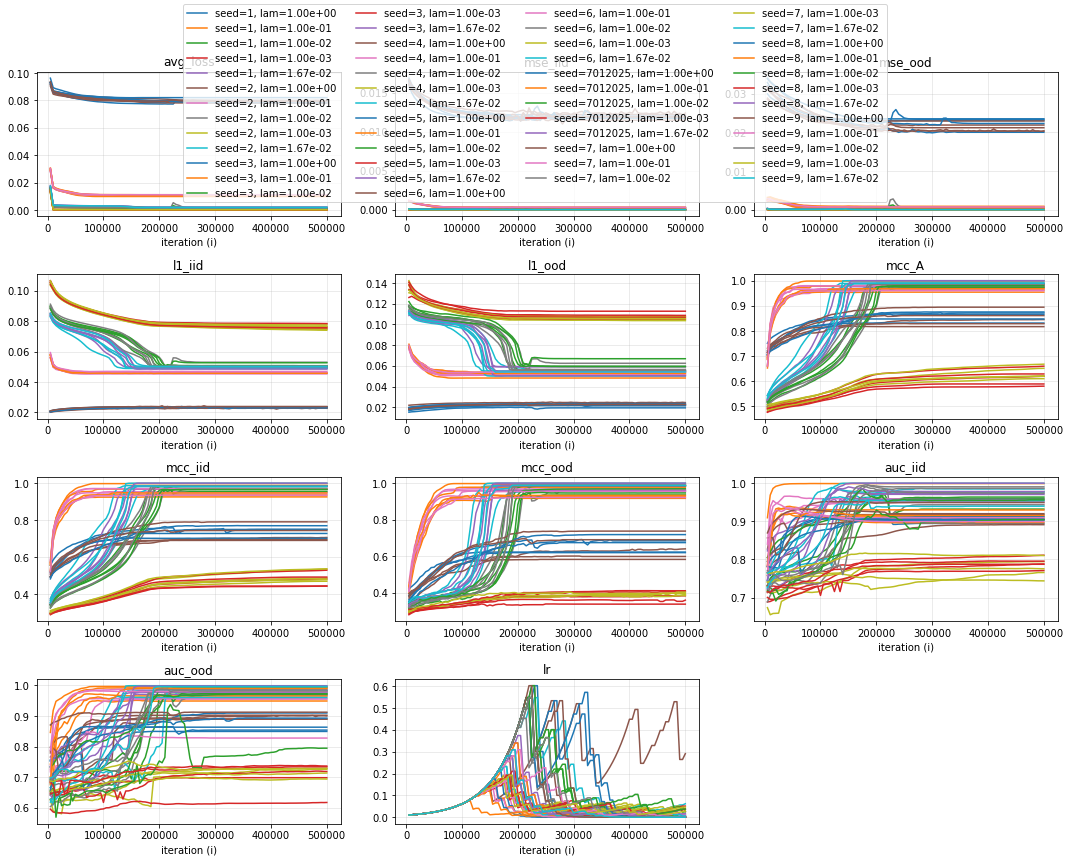

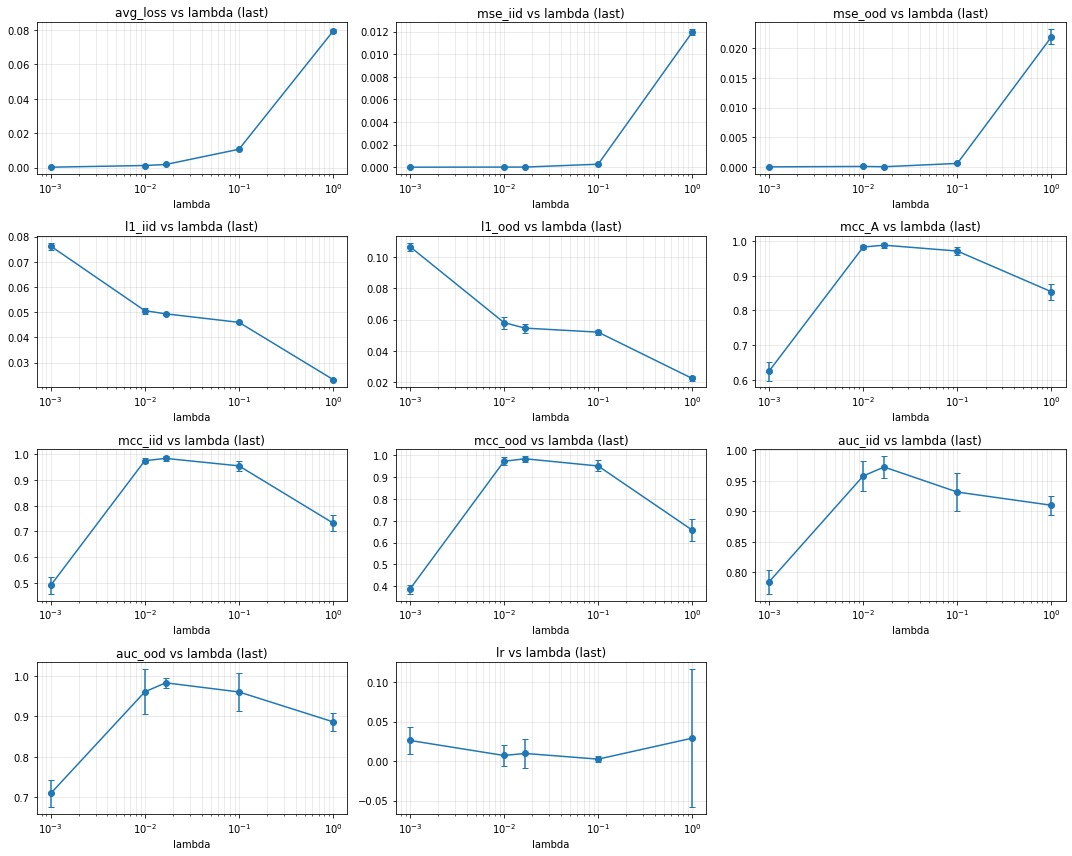

In [1]:
import pickle
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ---- Configure inputs ----
# Option A: Explicit list
# filelist = [
#     'results_seed=1_supervised=False_lambda=1.6681e-02.pickle',
#     'results_seed=2_supervised=False_lambda=1.6681e-02.pickle',
#     'results_seed=3_supervised=False_lambda=1.6681e-02.pickle',
#     'results_seed=7012025_supervised=False_lambda=1.6681e-02.pickle',
# ]
# glob_pattern = 'results_seed=*_*lambda=*.pickle'
glob_pattern = 'results_seed=*_supervised=False_lambda=*_m=47_k=10_npoints=1000_n=100.pickle'
filelist = sorted(glob.glob(glob_pattern))

# Labels to include (leave empty to auto-detect 1D time-series tracked over iterations)
labels_filter = [
    'avg_loss', 'mse_iid', 'mse_ood', 'l1_iid', 'l1_ood',
    'mcc_A', 'mcc_iid', 'mcc_ood', 'auc_iid', 'auc_ood', 'lr'
]

# Summary statistic for lambda plots: 'last' or 'max'
summary_stat = 'last'


def load_log(filename):
    with open(filename, 'rb') as handle:
        log = pickle.load(handle)
    # Ensure metadata is present; fallback to parsing filename
    lam = log['lam'] if 'lam' in log and not isinstance(log['lam'], list) else None
    seed = log.get('seed', None)
    supervised = log.get('supervised', None)
    if lam is None:
        m = re.search(r'lambda=([0-9\.e\-]+)', filename)
        if m:
            lam = float(m.group(1))
    if seed is None:
        m = re.search(r'results_seed=(\d+)', filename)
        if m:
            seed = int(m.group(1))
    if supervised is None:
        m = re.search(r'supervised=(True|False)', filename)
        if m:
            supervised = (m.group(1) == 'True')
    log['_meta'] = {'lam': lam, 'seed': seed, 'supervised': supervised, 'filename': filename}
    return log


def detect_series_keys(log):
    i_series = log.get('i', [])
    L = len(i_series) if isinstance(i_series, list) else None
    keys = []
    for k, v in log.items():
        if k.startswith('_'):
            continue
        if k in ['Z_iid_', 'Z_ood_', 'A_']:
            continue
        if isinstance(v, list) and (L is not None) and len(v) == L:
            keys.append(k)
    return keys


def make_subplot_grid(n, max_cols=3):
    cols = min(max_cols, n) if n > 0 else 1
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 3), squeeze=False)
    axes_flat = axes.flatten()
    # Hide unused axes
    for ax in axes_flat[n:]:
        ax.set_visible(False)
    return fig, axes_flat


# ---- Load logs ----
logs = [load_log(f) for f in filelist]
if len(logs) == 0:
    raise ValueError('No logs loaded. Check filelist or glob pattern.')

# Determine labels to plot
auto_labels = detect_series_keys(logs[0])
if labels_filter:
    labels_to_plot = [k for k in labels_filter if k in auto_labels]
else:
    labels_to_plot = auto_labels

# ---- Plots vs iteration (i) ----
fig_i, axes_i = make_subplot_grid(len(labels_to_plot), max_cols=3)
for idx, k in enumerate(labels_to_plot):
    ax = axes_i[idx]
    for log in logs:
        i_vals = log.get('i', [])
        y = log.get(k, None)
        if not isinstance(i_vals, list) or not isinstance(y, list) or len(i_vals) != len(y):
            continue
        meta = log['_meta']
        label = f"seed={meta['seed']}, lam={meta['lam']:.2e}"
        ax.plot(i_vals, y, label=label)
    ax.set_title(k)
    ax.set_xlabel('iteration (i)')
    ax.grid(True, alpha=0.3)
# One shared legend
handles, labels = axes_i[0].get_legend_handles_labels()
if handles:
    fig_i.legend(handles, labels, loc='upper center', ncol=min(4, len(labels)))
fig_i.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ---- Plots vs lambda (summary across time) ----
# Group values by lambda
by_lam = defaultdict(list)
for log in logs:
    by_lam[log['_meta']['lam']].append(log)

fig_lam, axes_lam = make_subplot_grid(len(labels_to_plot), max_cols=3)
for idx, k in enumerate(labels_to_plot):
    ax = axes_lam[idx]
    lam_vals, means, stds, counts = [], [], [], []
    for lam in sorted(by_lam.keys()):
        vals = []
        for log in by_lam[lam]:
            series = log.get(k, None)
            if isinstance(series, list) and len(series) > 0:
                if summary_stat == 'max':
                    vals.append(np.max(series))
                else:
                    vals.append(series[-1])
        if len(vals) == 0:
            continue
        lam_vals.append(lam)
        means.append(np.mean(vals))
        stds.append(np.std(vals))
        counts.append(len(vals))
    if len(lam_vals) == 0:
        continue
    ax.errorbar(lam_vals, means, yerr=stds, fmt='o-', capsize=3)
    ax.set_xscale('log')
    ax.set_title(f"{k} vs lambda ({summary_stat})")
    ax.set_xlabel('lambda')
    ax.grid(True, which='both', alpha=0.3)
fig_lam.tight_layout()
plt.semilogx()
plt.show()

m set to lower bound (changes with n)!!
Loaded 100 files matching: results_seed=*_supervised=False_lambda=1.6681e-02_m=*_k=10_npoints=1000_n=*.pickle


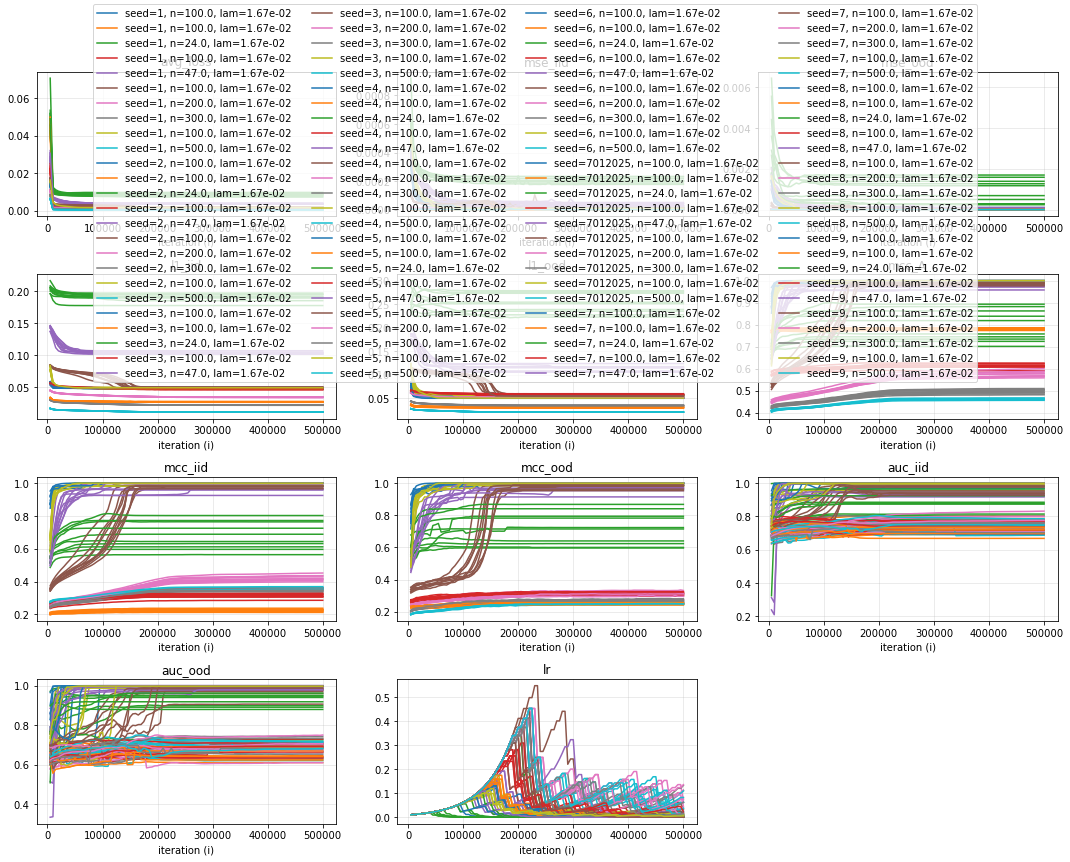

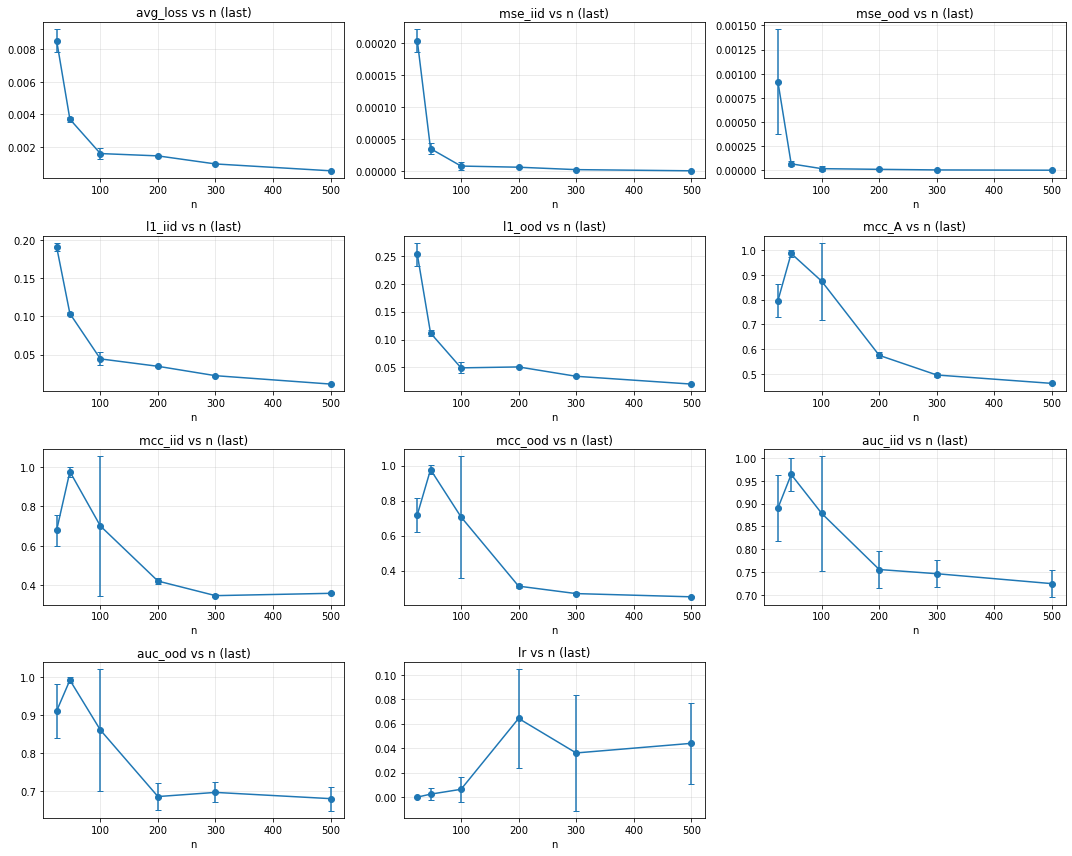

In [13]:
import pickle
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

### m set to lower bound (changes with n)!!
print("m set to lower bound (changes with n)!!")

# ---- Configure inputs ----
# Example: vary n, keep seed/lambda filter as desired
# glob_pattern = 'results_seed=*_supervised=False_lambda=1.6681e-02_m=47_k=10_npoints=1000_n=*.pickle'
glob_pattern = 'results_seed=*_supervised=False_lambda=1.6681e-02_m=*_k=10_npoints=1000_n=*.pickle'

filelist = sorted(glob.glob(glob_pattern))

# Labels to include (leave empty to auto-detect 1D time-series tracked over iterations)
labels_filter = [
    'avg_loss', 'mse_iid', 'mse_ood', 'l1_iid', 'l1_ood',
    'mcc_A', 'mcc_iid', 'mcc_ood', 'auc_iid', 'auc_ood', 'lr'
]

# Summary statistic for n plots: 'last' or 'max'
summary_stat = 'last'


def load_log(filename):
    with open(filename, 'rb') as handle:
        log = pickle.load(handle)
    # Metadata
    lam = log['lam'] if 'lam' in log and not isinstance(log['lam'], list) else None
    seed = log.get('seed', None)
    supervised = log.get('supervised', None)
    # Parse from filename if missing
    if lam is None:
        m = re.search(r'lambda=([0-9\.e\-]+)', filename)
        if m:
            lam = float(m.group(1))
    if seed is None:
        m = re.search(r'results_seed=(\d+)', filename)
        if m:
            seed = int(m.group(1))
    if supervised is None:
        m = re.search(r'supervised=(True|False)', filename)
        if m:
            supervised = (m.group(1) == 'True')
    # Parse n from filename
    n_val = None
    m = re.search(r'_n=([0-9\.e\-]+)', filename)
    if m:
        n_str = m.group(1)
        try:
            n_val = int(n_str)
        except ValueError:
            try:
                n_val = float(n_str)
            except ValueError:
                n_val = None
    log['_meta'] = {
        'lam': lam, 'seed': seed, 'supervised': supervised, 'n': n_val,
        'filename': filename
    }
    return log


def detect_series_keys(log):
    i_series = log.get('i', [])
    L = len(i_series) if isinstance(i_series, list) else None
    keys = []
    for k, v in log.items():
        if k.startswith('_'):
            continue
        if k in ['Z_iid_', 'Z_ood_', 'A_']:
            continue
        if isinstance(v, list) and (L is not None) and len(v) == L:
            keys.append(k)
    return keys


def make_subplot_grid(n, max_cols=3):
    cols = min(max_cols, n) if n > 0 else 1
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 3), squeeze=False)
    axes_flat = axes.flatten()
    for ax in axes_flat[n:]:
        ax.set_visible(False)
    return fig, axes_flat


# ---- Load logs ----
logs = [load_log(f) for f in filelist]
print(f"Loaded {len(logs)} files matching: {glob_pattern}")
if len(logs) == 0:
    raise ValueError('No logs loaded. Adjust glob_pattern.')

# Determine labels to plot
auto_labels = detect_series_keys(logs[0])
labels_to_plot = [k for k in labels_filter if k in auto_labels] if labels_filter else auto_labels

# ---- Plots vs iteration (i) ----
fig_i, axes_i = make_subplot_grid(len(labels_to_plot), max_cols=3)
for idx, k in enumerate(labels_to_plot):
    ax = axes_i[idx]
    for log in logs:
        i_vals = log.get('i', [])
        y = log.get(k, None)
        if not isinstance(i_vals, list) or not isinstance(y, list) or len(i_vals) != len(y):
            continue
        meta = log['_meta']
        lbl = f"seed={meta['seed']}, n={meta['n']}, lam={meta['lam']:.2e}"
        ax.plot(i_vals, y, label=lbl)
    ax.set_title(k)
    ax.set_xlabel('iteration (i)')
    ax.grid(True, alpha=0.3)
handles, labels = axes_i[0].get_legend_handles_labels()
if handles:
    fig_i.legend(handles, labels, loc='upper center', ncol=min(4, len(labels)))
fig_i.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ---- Plots vs n (summary across time) ----
by_n = defaultdict(list)
for log in logs:
    n_key = log['_meta'].get('n', None)
    if n_key is not None:
        by_n[n_key].append(log)

fig_n, axes_n = make_subplot_grid(len(labels_to_plot), max_cols=3)
for idx, k in enumerate(labels_to_plot):
    ax = axes_n[idx]
    n_vals, means, stds = [], [], []
    for n_key in sorted(by_n.keys(), key=lambda x: (isinstance(x, str), x)):
        vals = []
        for log in by_n[n_key]:
            series = log.get(k, None)
            if isinstance(series, list) and len(series) > 0:
                vals.append(np.max(series) if summary_stat == 'max' else series[-1])
        if len(vals) == 0:
            continue
        n_vals.append(n_key)
        means.append(np.mean(vals))
        stds.append(np.std(vals))
    if len(n_vals) == 0:
        continue
    ax.errorbar(n_vals, means, yerr=stds, fmt='o-', capsize=3)
    ax.set_title(f"{k} vs n ({summary_stat})")
    ax.set_xlabel('n')
    ax.grid(True, alpha=0.3)
fig_n.tight_layout()
plt.semilogx()
plt.show()

In [3]:
# import pickle
# import re
# import glob
# import numpy as np
# import matplotlib.pyplot as plt
# from collections import defaultdict

# # ---- Configure inputs ----
# # Example: vary npoints, keep n and other params fixed as desired
# glob_pattern = 'results_seed=*_supervised=False_lambda=1.6681e-02_m=100_k=10_npoints=*_n=100.pickle'
# filelist = sorted(glob.glob(glob_pattern))

# # Labels to include (leave empty to auto-detect 1D time-series tracked over iterations)
# labels_filter = [
#     'avg_loss', 'mse_iid', 'mse_ood', 'l1_iid', 'l1_ood',
#     'mcc_A', 'mcc_iid', 'mcc_ood', 'auc_iid', 'auc_ood', 'lr'
# ]

# # Summary statistic for npoints plots: 'last' or 'max'
# summary_stat = 'last'


# def load_log(filename):
#     with open(filename, 'rb') as handle:
#         log = pickle.load(handle)
#     # Metadata
#     lam = log['lam'] if 'lam' in log and not isinstance(log['lam'], list) else None
#     seed = log.get('seed', None)
#     supervised = log.get('supervised', None)
#     # Parse from filename if missing
#     if lam is None:
#         m = re.search(r'lambda=([0-9\.e\-]+)', filename)
#         if m:
#             lam = float(m.group(1))
#     if seed is None:
#         m = re.search(r'results_seed=(\d+)', filename)
#         if m:
#             seed = int(m.group(1))
#     if supervised is None:
#         m = re.search(r'supervised=(True|False)', filename)
#         if m:
#             supervised = (m.group(1) == 'True')
#     # Parse n and npoints from filename
#     n_val = None
#     m = re.search(r'_n=([0-9\.e\-]+)', filename)
#     if m:
#         n_str = m.group(1)
#         try:
#             n_val = int(n_str)
#         except ValueError:
#             try:
#                 n_val = float(n_str)
#             except ValueError:
#                 n_val = None
#     npoints_val = None
#     m = re.search(r'_npoints=([0-9\.e\-]+)', filename)
#     if m:
#         np_str = m.group(1)
#         try:
#             npoints_val = int(np_str)
#         except ValueError:
#             try:
#                 npoints_val = float(np_str)
#             except ValueError:
#                 npoints_val = None
#     log['_meta'] = {
#         'lam': lam, 'seed': seed, 'supervised': supervised,
#         'n': n_val, 'npoints': npoints_val,
#         'filename': filename
#     }
#     return log


# def detect_series_keys(log):
#     i_series = log.get('i', [])
#     L = len(i_series) if isinstance(i_series, list) else None
#     keys = []
#     for k, v in log.items():
#         if k.startswith('_'):
#             continue
#         if k in ['Z_iid_', 'Z_ood_', 'A_']:
#             continue
#         if isinstance(v, list) and (L is not None) and len(v) == L:
#             keys.append(k)
#     return keys


# def make_subplot_grid(n, max_cols=3):
#     cols = min(max_cols, n) if n > 0 else 1
#     rows = int(np.ceil(n / cols))
#     fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 3), squeeze=False)
#     axes_flat = axes.flatten()
#     for ax in axes_flat[n:]:
#         ax.set_visible(False)
#     return fig, axes_flat


# # ---- Load logs ----
# logs = [load_log(f) for f in filelist]
# print(f"Loaded {len(logs)} files matching: {glob_pattern}")
# if len(logs) == 0:
#     raise ValueError('No logs loaded. Adjust glob_pattern.')

# # Determine labels to plot
# auto_labels = detect_series_keys(logs[0])
# labels_to_plot = [k for k in labels_filter if k in auto_labels] if labels_filter else auto_labels

# # ---- Plots vs iteration (i) ----
# fig_i, axes_i = make_subplot_grid(len(labels_to_plot), max_cols=3)
# for idx, k in enumerate(labels_to_plot):
#     ax = axes_i[idx]
#     for log in logs:
#         i_vals = log.get('i', [])
#         y = log.get(k, None)
#         if not isinstance(i_vals, list) or not isinstance(y, list) or len(i_vals) != len(y):
#             continue
#         meta = log['_meta']
#         lbl = f"seed={meta['seed']}, npoints={meta['npoints']}, n={meta['n']}, lam={meta['lam']:.2e}"
#         ax.plot(i_vals, y, label=lbl)
#     ax.set_title(k)
#     ax.set_xlabel('iteration (i)')
#     ax.grid(True, alpha=0.3)
# handles, labels = axes_i[0].get_legend_handles_labels()
# if handles:
#     fig_i.legend(handles, labels, loc='upper center', ncol=min(4, len(labels)))
# fig_i.tight_layout(rect=[0, 0, 1, 0.95])
# plt.show()

# # ---- Plots vs npoints (summary across time) ----
# by_npoints = defaultdict(list)
# for log in logs:
#     np_key = log['_meta'].get('npoints', None)
#     if np_key is not None:
#         by_npoints[np_key].append(log)

# fig_np, axes_np = make_subplot_grid(len(labels_to_plot), max_cols=3)
# for idx, k in enumerate(labels_to_plot):
#     ax = axes_np[idx]
#     x_vals, means, stds = [], [], []
#     for np_key in sorted(by_npoints.keys(), key=lambda x: (isinstance(x, str), x)):
#         vals = []
#         for log in by_npoints[np_key]:
#             series = log.get(k, None)
#             if isinstance(series, list) and len(series) > 0:
#                 vals.append(np.max(series) if summary_stat == 'max' else series[-1])
#         if len(vals) == 0:
#             continue
#         x_vals.append(np_key)
#         means.append(np.mean(vals))
#         stds.append(np.std(vals))
#     if len(x_vals) == 0:
#         continue
#     ax.errorbar(x_vals, means, yerr=stds, fmt='o-', capsize=3)
#     ax.set_title(f"{k} vs npoints ({summary_stat})")
#     ax.set_xlabel('npoints')
#     ax.grid(True, alpha=0.3)
# fig_np.tight_layout()
# plt.show()

In [4]:
# import pickle
# import re
# import glob
# import numpy as np
# import matplotlib.pyplot as plt
# from collections import defaultdict

# # ---- Configure inputs ----
# # Example: vary npoints, keep n and other params fixed as desired
# # glob_pattern = 'results_seed=*_supervised=False_lambda=1.6681e-02_m=47_k=10_npoints=*_n=100.pickle'
# glob_pattern = 'results_seed=*_supervised=False_lambda=1.6681e-02_m=47_k=10_npoints=*_n=100.pickle'

# filelist = sorted(glob.glob(glob_pattern))

# # Labels to include (leave empty to auto-detect 1D time-series tracked over iterations)
# labels_filter = [
#     'avg_loss', 'mse_iid', 'mse_ood', 'l1_iid', 'l1_ood',
#     'mcc_A', 'mcc_iid', 'mcc_ood', 'auc_iid', 'auc_ood', 'lr'
# ]

# # Summary statistic for npoints plots: 'last' or 'max'
# summary_stat = 'last'


# def load_log(filename):
#     with open(filename, 'rb') as handle:
#         log = pickle.load(handle)
#     # Metadata
#     lam = log['lam'] if 'lam' in log and not isinstance(log['lam'], list) else None
#     seed = log.get('seed', None)
#     supervised = log.get('supervised', None)
#     # Parse from filename if missing
#     if lam is None:
#         m = re.search(r'lambda=([0-9\.e\-]+)', filename)
#         if m:
#             lam = float(m.group(1))
#     if seed is None:
#         m = re.search(r'results_seed=(\d+)', filename)
#         if m:
#             seed = int(m.group(1))
#     if supervised is None:
#         m = re.search(r'supervised=(True|False)', filename)
#         if m:
#             supervised = (m.group(1) == 'True')
#     # Parse n and npoints from filename
#     n_val = None
#     m = re.search(r'_n=([0-9\.e\-]+)', filename)
#     if m:
#         n_str = m.group(1)
#         try:
#             n_val = int(n_str)
#         except ValueError:
#             try:
#                 n_val = float(n_str)
#             except ValueError:
#                 n_val = None
#     npoints_val = None
#     m = re.search(r'_npoints=([0-9\.e\-]+)', filename)
#     if m:
#         np_str = m.group(1)
#         try:
#             npoints_val = int(np_str)
#         except ValueError:
#             try:
#                 npoints_val = float(np_str)
#             except ValueError:
#                 npoints_val = None
#     log['_meta'] = {
#         'lam': lam, 'seed': seed, 'supervised': supervised,
#         'n': n_val, 'npoints': npoints_val,
#         'filename': filename
#     }
#     return log


# def detect_series_keys(log):
#     i_series = log.get('i', [])
#     L = len(i_series) if isinstance(i_series, list) else None
#     keys = []
#     for k, v in log.items():
#         if k.startswith('_'):
#             continue
#         if k in ['Z_iid_', 'Z_ood_', 'A_']:
#             continue
#         if isinstance(v, list) and (L is not None) and len(v) == L:
#             keys.append(k)
#     return keys


# def make_subplot_grid(n, max_cols=3):
#     cols = min(max_cols, n) if n > 0 else 1
#     rows = int(np.ceil(n / cols))
#     fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 3), squeeze=False)
#     axes_flat = axes.flatten()
#     for ax in axes_flat[n:]:
#         ax.set_visible(False)
#     return fig, axes_flat


# # ---- Load logs ----
# logs = [load_log(f) for f in filelist]
# print(f"Loaded {len(logs)} files matching: {glob_pattern}")
# if len(logs) == 0:
#     raise ValueError('No logs loaded. Adjust glob_pattern.')

# # Determine labels to plot
# auto_labels = detect_series_keys(logs[0])
# labels_to_plot = [k for k in labels_filter if k in auto_labels] if labels_filter else auto_labels

# # ---- Plots vs iteration (i) ----
# fig_i, axes_i = make_subplot_grid(len(labels_to_plot), max_cols=3)
# for idx, k in enumerate(labels_to_plot):
#     ax = axes_i[idx]
#     for log in logs:
#         i_vals = log.get('i', [])
#         y = log.get(k, None)
#         if not isinstance(i_vals, list) or not isinstance(y, list) or len(i_vals) != len(y):
#             continue
#         meta = log['_meta']
#         lbl = f"seed={meta['seed']}, npoints={meta['npoints']}, n={meta['n']}, lam={meta['lam']:.2e}"
#         ax.plot(i_vals, y, label=lbl)
#     ax.set_title(k)
#     ax.set_xlabel('iteration (i)')
#     ax.grid(True, alpha=0.3)
# handles, labels = axes_i[0].get_legend_handles_labels()
# if handles:
#     fig_i.legend(handles, labels, loc='upper center', ncol=min(4, len(labels)))
# fig_i.tight_layout(rect=[0, 0, 1, 0.95])
# plt.show()

# # ---- Plots vs npoints (summary across time) ----
# by_npoints = defaultdict(list)
# for log in logs:
#     np_key = log['_meta'].get('npoints', None)
#     if np_key is not None:
#         by_npoints[np_key].append(log)

# fig_np, axes_np = make_subplot_grid(len(labels_to_plot), max_cols=3)
# for idx, k in enumerate(labels_to_plot):
#     ax = axes_np[idx]
#     x_vals, means, stds = [], [], []
#     for np_key in sorted(by_npoints.keys(), key=lambda x: (isinstance(x, str), x)):
#         vals = []
#         for log in by_npoints[np_key]:
#             series = log.get(k, None)
#             if isinstance(series, list) and len(series) > 0:
#                 vals.append(np.max(series) if summary_stat == 'max' else series[-1])
#         if len(vals) == 0:
#             continue
#         x_vals.append(np_key)
#         means.append(np.mean(vals))
#         stds.append(np.std(vals))
#     if len(x_vals) == 0:
#         continue
#     ax.errorbar(x_vals, means, yerr=stds, fmt='o-', capsize=3)
#     ax.set_title(f"{k} vs npoints ({summary_stat})")
#     ax.set_xlabel('npoints')
#     ax.grid(True, alpha=0.3)
# fig_np.tight_layout()
# plt.show()

Loaded 130 files matching: results_seed=*_supervised=False_lambda=1.6681e-02_m=47_k=10_npoints=*_n=100.pickle


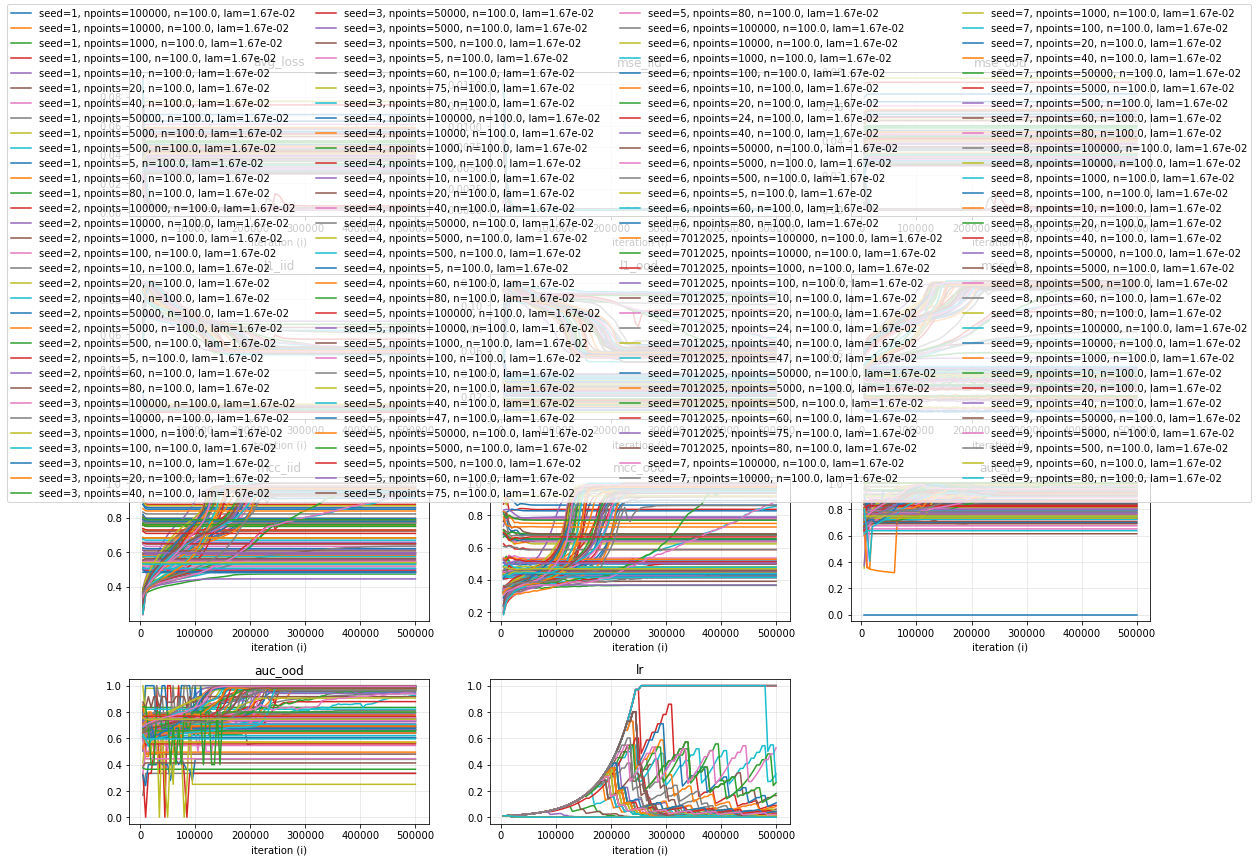

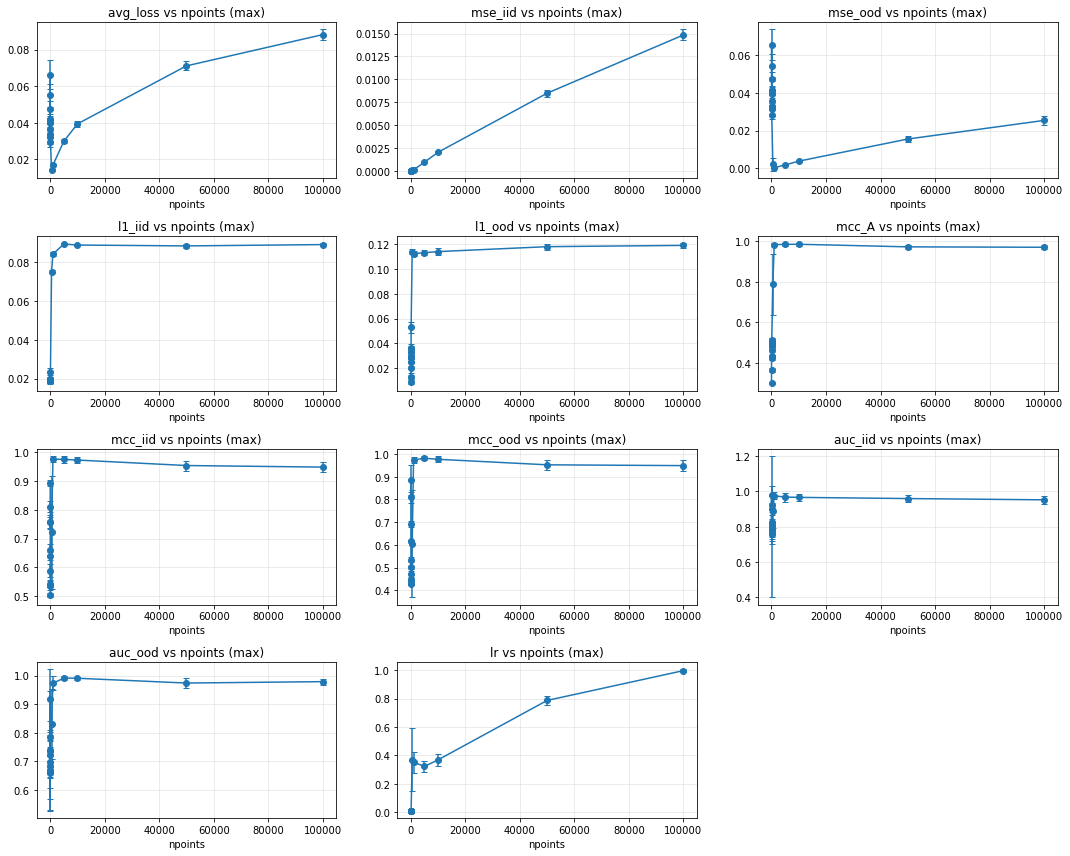

In [1]:
import pickle
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ---- Configure inputs ----
# Example: vary npoints, keep n and other params fixed as desired
glob_pattern = 'results_seed=*_supervised=False_lambda=1.6681e-02_m=47_k=10_npoints=*_n=100.pickle'
filelist = sorted(glob.glob(glob_pattern))

# Labels to include (leave empty to auto-detect 1D time-series tracked over iterations)
labels_filter = [
    'avg_loss', 'mse_iid', 'mse_ood', 'l1_iid', 'l1_ood',
    'mcc_A', 'mcc_iid', 'mcc_ood', 'auc_iid', 'auc_ood', 'lr'
]

# Summary statistic for npoints plots: 'last' or 'max'
summary_stat = 'max'


def load_log(filename):
    with open(filename, 'rb') as handle:
        log = pickle.load(handle)
    # Metadata
    lam = log['lam'] if 'lam' in log and not isinstance(log['lam'], list) else None
    seed = log.get('seed', None)
    supervised = log.get('supervised', None)
    # Parse from filename if missing
    if lam is None:
        m = re.search(r'lambda=([0-9\.e\-]+)', filename)
        if m:
            lam = float(m.group(1))
    if seed is None:
        m = re.search(r'results_seed=(\d+)', filename)
        if m:
            seed = int(m.group(1))
    if supervised is None:
        m = re.search(r'supervised=(True|False)', filename)
        if m:
            supervised = (m.group(1) == 'True')
    # Parse n and npoints from filename
    n_val = None
    m = re.search(r'_n=([0-9\.e\-]+)', filename)
    if m:
        n_str = m.group(1)
        try:
            n_val = int(n_str)
        except ValueError:
            try:
                n_val = float(n_str)
            except ValueError:
                n_val = None
    npoints_val = None
    m = re.search(r'_npoints=([0-9\.e\-]+)', filename)
    if m:
        np_str = m.group(1)
        try:
            npoints_val = int(np_str)
        except ValueError:
            try:
                npoints_val = float(np_str)
            except ValueError:
                npoints_val = None
    log['_meta'] = {
        'lam': lam, 'seed': seed, 'supervised': supervised,
        'n': n_val, 'npoints': npoints_val,
        'filename': filename
    }
    return log


def detect_series_keys(log):
    i_series = log.get('i', [])
    L = len(i_series) if isinstance(i_series, list) else None
    keys = []
    for k, v in log.items():
        if k.startswith('_'):
            continue
        if k in ['Z_iid_', 'Z_ood_', 'A_']:
            continue
        if isinstance(v, list) and (L is not None) and len(v) == L:
            keys.append(k)
    return keys


def make_subplot_grid(n, max_cols=3):
    cols = min(max_cols, n) if n > 0 else 1
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 3), squeeze=False)
    axes_flat = axes.flatten()
    for ax in axes_flat[n:]:
        ax.set_visible(False)
    return fig, axes_flat


# ---- Load logs ----
logs = [load_log(f) for f in filelist]
print(f"Loaded {len(logs)} files matching: {glob_pattern}")
if len(logs) == 0:
    raise ValueError('No logs loaded. Adjust glob_pattern.')

# Determine labels to plot
auto_labels = detect_series_keys(logs[0])
labels_to_plot = [k for k in labels_filter if k in auto_labels] if labels_filter else auto_labels

# ---- Plots vs iteration (i) ----
fig_i, axes_i = make_subplot_grid(len(labels_to_plot), max_cols=3)
for idx, k in enumerate(labels_to_plot):
    ax = axes_i[idx]
    for log in logs:
        i_vals = log.get('i', [])
        y = log.get(k, None)
        if not isinstance(i_vals, list) or not isinstance(y, list) or len(i_vals) != len(y):
            continue
        meta = log['_meta']
        lbl = f"seed={meta['seed']}, npoints={meta['npoints']}, n={meta['n']}, lam={meta['lam']:.2e}"
        ax.plot(i_vals, y, label=lbl)
    ax.set_title(k)
    ax.set_xlabel('iteration (i)')
    ax.grid(True, alpha=0.3)
handles, labels = axes_i[0].get_legend_handles_labels()
if handles:
    fig_i.legend(handles, labels, loc='upper center', ncol=min(4, len(labels)))
fig_i.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ---- Plots vs npoints (summary across time) ----
by_npoints = defaultdict(list)
for log in logs:
    np_key = log['_meta'].get('npoints', None)
    if np_key is not None:
        by_npoints[np_key].append(log)

fig_np, axes_np = make_subplot_grid(len(labels_to_plot), max_cols=3)
for idx, k in enumerate(labels_to_plot):
    ax = axes_np[idx]
    x_vals, means, stds = [], [], []
    for np_key in sorted(by_npoints.keys(), key=lambda x: (isinstance(x, str), x)):
        vals = []
        for log in by_npoints[np_key]:
            series = log.get(k, None)
            if isinstance(series, list) and len(series) > 0:
                vals.append(np.max(series) if summary_stat == 'max' else series[-1])
        if len(vals) == 0:
            continue
        x_vals.append(np_key)
        means.append(np.mean(vals))
        stds.append(np.std(vals))
    if len(x_vals) == 0:
        continue
    ax.errorbar(x_vals, means, yerr=stds, fmt='o-', capsize=3)
    ax.set_title(f"{k} vs npoints ({summary_stat})")
    ax.set_xlabel('npoints')
    ax.grid(True, alpha=0.3)
fig_np.tight_layout()
plt.semilogx()
plt.show()

Loaded 90 files matching: results_seed=*_supervised=False_lambda=1.6681e-02_m=*_k=*_npoints=1000_n=100.pickle


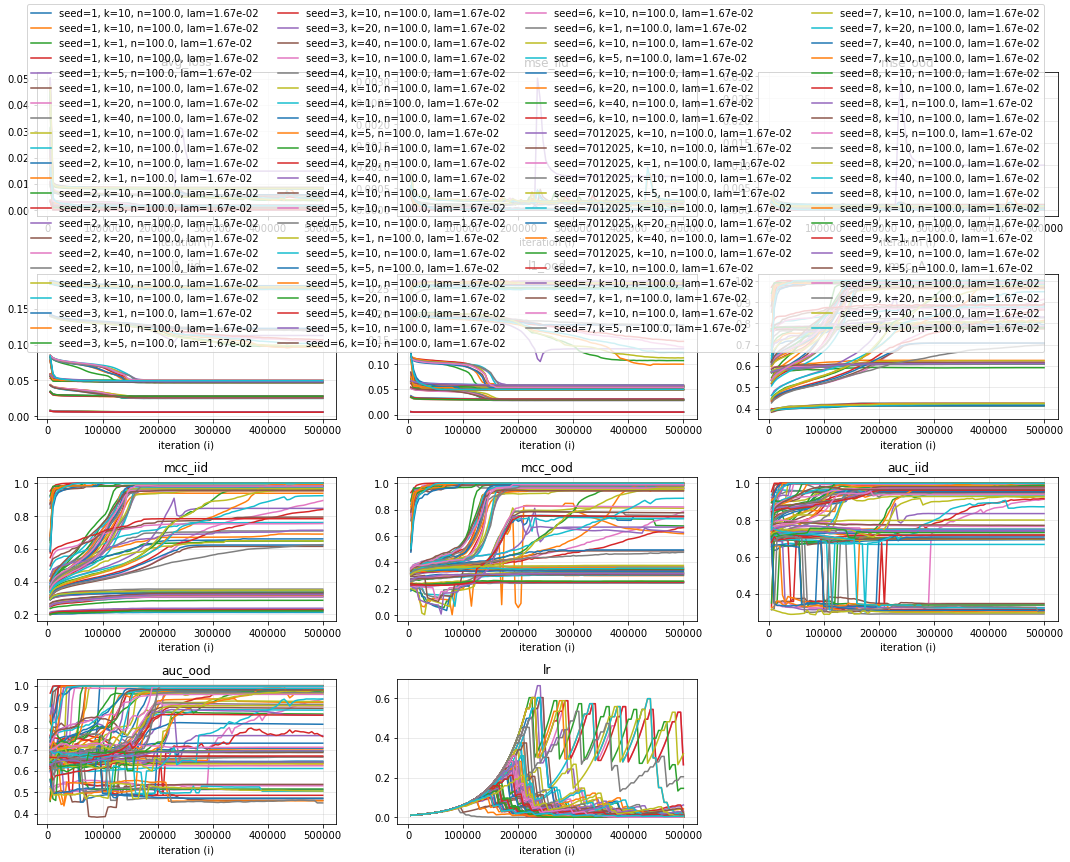

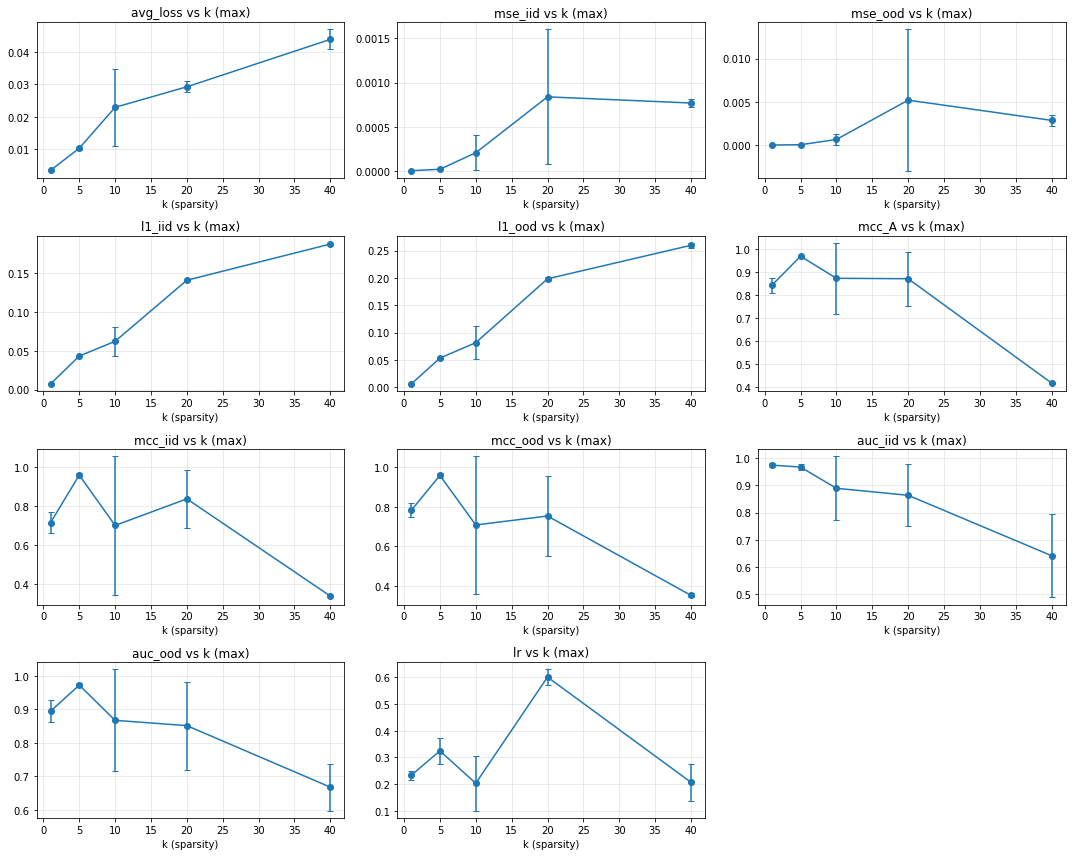

In [ ]:
import pickle
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

print('m set automatically according to k!!!')

# ---- Configure inputs ----
# Example: vary k, keep n and other params fixed as desired
# glob_pattern = 'results_seed=*_supervised=False_lambda=1.6681e-02_m=47_k=*_npoints=1000_n=100.pickle'
glob_pattern = 'results_seed=*_supervised=False_lambda=1.6681e-02_m=*_k=*_npoints=1000_n=100.pickle'
filelist = sorted(glob.glob(glob_pattern))

# Labels to include (leave empty to auto-detect 1D time-series tracked over iterations)
labels_filter = [
    'avg_loss', 'mse_iid', 'mse_ood', 'l1_iid', 'l1_ood',
    'mcc_A', 'mcc_iid', 'mcc_ood', 'auc_iid', 'auc_ood', 'lr'
]

# Summary statistic for k plots: 'last' or 'max'
summary_stat = 'max'


def load_log(filename):
    with open(filename, 'rb') as handle:
        log = pickle.load(handle)
    # Metadata
    lam = log['lam'] if 'lam' in log and not isinstance(log['lam'], list) else None
    seed = log.get('seed', None)
    supervised = log.get('supervised', None)
    # Parse from filename if missing
    if lam is None:
        m = re.search(r'lambda=([0-9\.e\-]+)', filename)
        if m:
            lam = float(m.group(1))
    if seed is None:
        m = re.search(r'results_seed=(\d+)', filename)
        if m:
            seed = int(m.group(1))
    if supervised is None:
        m = re.search(r'supervised=(True|False)', filename)
        if m:
            supervised = (m.group(1) == 'True')
    # Parse n, k, and npoints from filename
    n_val = None
    m = re.search(r'_n=([0-9\.e\-]+)', filename)
    if m:
        n_str = m.group(1)
        try:
            n_val = int(n_str)
        except ValueError:
            try:
                n_val = float(n_str)
            except ValueError:
                n_val = None
    k_val = None
    m = re.search(r'_k=([0-9\.e\-]+)', filename)
    if m:
        k_str = m.group(1)
        try:
            k_val = int(k_str)
        except ValueError:
            try:
                k_val = float(k_str)
            except ValueError:
                k_val = None
    npoints_val = None
    m = re.search(r'_npoints=([0-9\.e\-]+)', filename)
    if m:
        np_str = m.group(1)
        try:
            npoints_val = int(np_str)
        except ValueError:
            try:
                npoints_val = float(np_str)
            except ValueError:
                npoints_val = None
    log['_meta'] = {
        'lam': lam, 'seed': seed, 'supervised': supervised,
        'n': n_val, 'k': k_val, 'npoints': npoints_val,
        'filename': filename
    }
    return log


def detect_series_keys(log):
    i_series = log.get('i', [])
    L = len(i_series) if isinstance(i_series, list) else None
    keys = []
    for k, v in log.items():
        if k.startswith('_'):
            continue
        if k in ['Z_iid_', 'Z_ood_', 'A_']:
            continue
        if isinstance(v, list) and (L is not None) and len(v) == L:
            keys.append(k)
    return keys


def make_subplot_grid(n, max_cols=3):
    cols = min(max_cols, n) if n > 0 else 1
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 3), squeeze=False)
    axes_flat = axes.flatten()
    for ax in axes_flat[n:]:
        ax.set_visible(False)
    return fig, axes_flat


# ---- Load logs ----
logs = [load_log(f) for f in filelist]
print(f"Loaded {len(logs)} files matching: {glob_pattern}")
if len(logs) == 0:
    raise ValueError('No logs loaded. Adjust glob_pattern.')

# Determine labels to plot
auto_labels = detect_series_keys(logs[0])
labels_to_plot = [k for k in labels_filter if k in auto_labels] if labels_filter else auto_labels

# ---- Plots vs iteration (i) ----
fig_i, axes_i = make_subplot_grid(len(labels_to_plot), max_cols=3)
for idx, k in enumerate(labels_to_plot):
    ax = axes_i[idx]
    for log in logs:
        i_vals = log.get('i', [])
        y = log.get(k, None)
        if not isinstance(i_vals, list) or not isinstance(y, list) or len(i_vals) != len(y):
            continue
        meta = log['_meta']
        lbl = f"seed={meta['seed']}, k={meta['k']}, n={meta['n']}, lam={meta['lam']:.2e}"
        ax.plot(i_vals, y, label=lbl)
    ax.set_title(k)
    ax.set_xlabel('iteration (i)')
    ax.grid(True, alpha=0.3)
handles, labels = axes_i[0].get_legend_handles_labels()
if handles:
    fig_i.legend(handles, labels, loc='upper center', ncol=min(4, len(labels)))
fig_i.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ---- Plots vs k (summary across time) ----
by_k = defaultdict(list)
for log in logs:
    k_key = log['_meta'].get('k', None)
    if k_key is not None:
        by_k[k_key].append(log)

fig_k, axes_k = make_subplot_grid(len(labels_to_plot), max_cols=3)
for idx, k in enumerate(labels_to_plot):
    ax = axes_k[idx]
    x_vals, means, stds = [], [], []
    for k_key in sorted(by_k.keys(), key=lambda x: (isinstance(x, str), x)):
        vals = []
        for log in by_k[k_key]:
            series = log.get(k, None)
            if isinstance(series, list) and len(series) > 0:
                vals.append(np.max(series) if summary_stat == 'max' else series[-1])
        if len(vals) == 0:
            continue
        x_vals.append(k_key)
        means.append(np.mean(vals))
        stds.append(np.std(vals))
    if len(x_vals) == 0:
        continue
    ax.errorbar(x_vals, means, yerr=stds, fmt='o-', capsize=3)
    ax.set_title(f"{k} vs k ({summary_stat})")
    ax.set_xlabel('k (sparsity)')
    ax.grid(True, alpha=0.3)
fig_k.tight_layout()
plt.semilogx()
plt.show()

Loaded 50 files matching: results_seed=*_supervised=False_lambda=1.6681e-02_m=*_k=10_npoints=1000_n=100.pickle


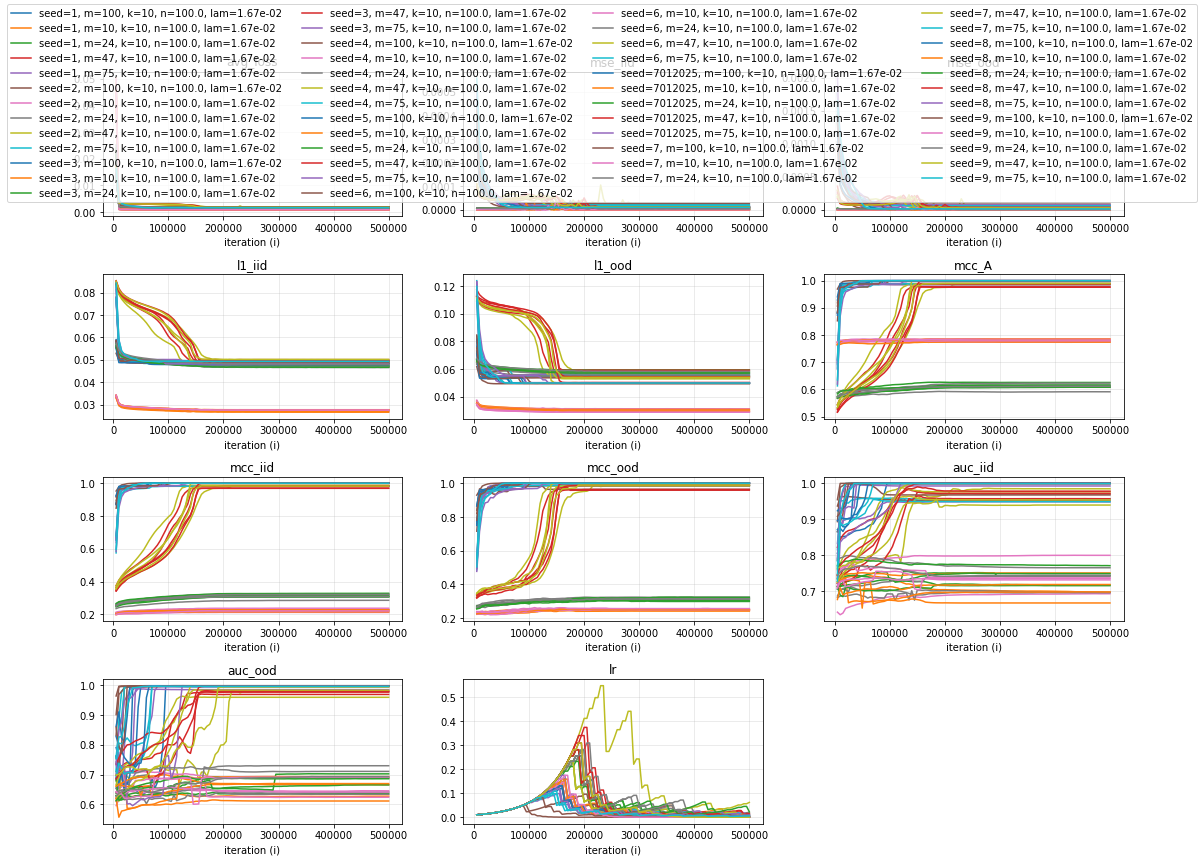

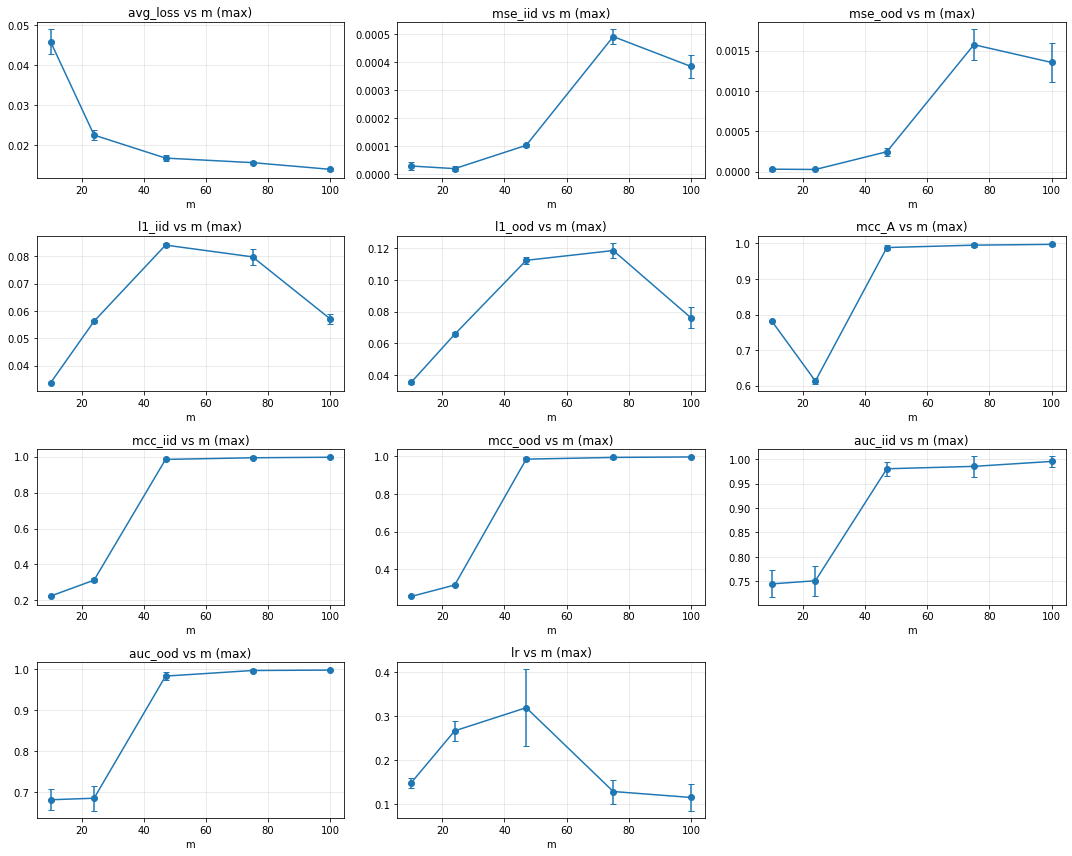

In [9]:
import pickle
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ---- Configure inputs ----
# Example: vary m, keep k and other params fixed as desired
glob_pattern = 'results_seed=*_supervised=False_lambda=1.6681e-02_m=*_k=10_npoints=1000_n=100.pickle'
filelist = sorted(glob.glob(glob_pattern))

# Labels to include (leave empty to auto-detect 1D time-series tracked over iterations)
labels_filter = [
    'avg_loss', 'mse_iid', 'mse_ood', 'l1_iid', 'l1_ood',
    'mcc_A', 'mcc_iid', 'mcc_ood', 'auc_iid', 'auc_ood', 'lr'
]

# Summary statistic for m plots: 'last' or 'max'
summary_stat = 'max'


def load_log(filename):
    with open(filename, 'rb') as handle:
        log = pickle.load(handle)
    # Metadata
    lam = log['lam'] if 'lam' in log and not isinstance(log['lam'], list) else None
    seed = log.get('seed', None)
    supervised = log.get('supervised', None)
    # Parse from filename if missing
    if lam is None:
        m = re.search(r'lambda=([0-9\.e\-]+)', filename)
        if m:
            lam = float(m.group(1))
    if seed is None:
        m = re.search(r'results_seed=(\d+)', filename)
        if m:
            seed = int(m.group(1))
    if supervised is None:
        m = re.search(r'supervised=(True|False)', filename)
        if m:
            supervised = (m.group(1) == 'True')
    # Parse n, k, m, and npoints from filename
    n_val = None
    m = re.search(r'_n=([0-9\.e\-]+)', filename)
    if m:
        n_str = m.group(1)
        try:
            n_val = int(n_str)
        except ValueError:
            try:
                n_val = float(n_str)
            except ValueError:
                n_val = None
    k_val = None
    m = re.search(r'_k=([0-9\.e\-]+)', filename)
    if m:
        k_str = m.group(1)
        try:
            k_val = int(k_str)
        except ValueError:
            try:
                k_val = float(k_str)
            except ValueError:
                k_val = None
    m_val = None
    m = re.search(r'_m=([0-9\.e\-]+)', filename)
    if m:
        m_str = m.group(1)
        try:
            m_val = int(m_str)
        except ValueError:
            try:
                m_val = float(m_str)
            except ValueError:
                m_val = None
    npoints_val = None
    m = re.search(r'_npoints=([0-9\.e\-]+)', filename)
    if m:
        np_str = m.group(1)
        try:
            npoints_val = int(np_str)
        except ValueError:
            try:
                npoints_val = float(np_str)
            except ValueError:
                npoints_val = None
    log['_meta'] = {
        'lam': lam, 'seed': seed, 'supervised': supervised,
        'n': n_val, 'k': k_val, 'm': m_val, 'npoints': npoints_val,
        'filename': filename
    }
    return log


def detect_series_keys(log):
    i_series = log.get('i', [])
    L = len(i_series) if isinstance(i_series, list) else None
    keys = []
    for k, v in log.items():
        if k.startswith('_'):
            continue
        if k in ['Z_iid_', 'Z_ood_', 'A_']:
            continue
        if isinstance(v, list) and (L is not None) and len(v) == L:
            keys.append(k)
    return keys


def make_subplot_grid(n, max_cols=3):
    cols = min(max_cols, n) if n > 0 else 1
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 3), squeeze=False)
    axes_flat = axes.flatten()
    for ax in axes_flat[n:]:
        ax.set_visible(False)
    return fig, axes_flat


# ---- Load logs ----
logs = [load_log(f) for f in filelist]
print(f"Loaded {len(logs)} files matching: {glob_pattern}")
if len(logs) == 0:
    raise ValueError('No logs loaded. Adjust glob_pattern.')

# Determine labels to plot
auto_labels = detect_series_keys(logs[0])
labels_to_plot = [k for k in labels_filter if k in auto_labels] if labels_filter else auto_labels

# ---- Plots vs iteration (i) ----
fig_i, axes_i = make_subplot_grid(len(labels_to_plot), max_cols=3)
for idx, k in enumerate(labels_to_plot):
    ax = axes_i[idx]
    for log in logs:
        i_vals = log.get('i', [])
        y = log.get(k, None)
        if not isinstance(i_vals, list) or not isinstance(y, list) or len(i_vals) != len(y):
            continue
        meta = log['_meta']
        lbl = f"seed={meta['seed']}, m={meta['m']}, k={meta['k']}, n={meta['n']}, lam={meta['lam']:.2e}"
        ax.plot(i_vals, y, label=lbl)
    ax.set_title(k)
    ax.set_xlabel('iteration (i)')
    ax.grid(True, alpha=0.3)
handles, labels = axes_i[0].get_legend_handles_labels()
if handles:
    fig_i.legend(handles, labels, loc='upper center', ncol=min(4, len(labels)))
fig_i.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ---- Plots vs m (summary across time) ----
by_m = defaultdict(list)
for log in logs:
    m_key = log['_meta'].get('m', None)
    if m_key is not None:
        by_m[m_key].append(log)

fig_m, axes_m = make_subplot_grid(len(labels_to_plot), max_cols=3)
for idx, k in enumerate(labels_to_plot):
    ax = axes_m[idx]
    x_vals, means, stds = [], [], []
    for m_key in sorted(by_m.keys(), key=lambda x: (isinstance(x, str), x)):
        vals = []
        for log in by_m[m_key]:
            series = log.get(k, None)
            if isinstance(series, list) and len(series) > 0:
                vals.append(np.max(series) if summary_stat == 'max' else series[-1])
        if len(vals) == 0:
            continue
        x_vals.append(m_key)
        means.append(np.mean(vals))
        stds.append(np.std(vals))
    if len(x_vals) == 0:
        continue
    ax.errorbar(x_vals, means, yerr=stds, fmt='o-', capsize=3)
    ax.set_title(f"{k} vs m ({summary_stat})")
    ax.set_xlabel('m')
    ax.grid(True, alpha=0.3)
fig_m.tight_layout()
plt.semilogx()
plt.show()